In [1]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset and Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel

# Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import StackingRegressor

# Optuna visualization
from optuna.visualization import plot_optimization_history

In [2]:
#importing datasets
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")
df = pd.concat([X, y], axis=1)

In [3]:
# Remove the artificial cap on the target (values >= 5.0)
df = df[df['MedHouseVal'] < 5.0]

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_clean[
            (df_clean[col] < Q1 - 1.5 * IQR) |
            (df_clean[col] > Q3 + 1.5 * IQR)
        ].index
        indices_to_drop.extend(outliers)
    return df_clean.drop(list(set(indices_to_drop)))

# Clean only the physical columns prone to errors
cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"Cleaned dataset: {df.shape}")

print("2. Manual Feature Engineering (Logs, Squares, Products, Ratios)...")

def generate_manual_combinations(df_input, cols_to_combine):
    df_eng = df_input.copy()
    
    # Exclude Lat/Lon/Cluster from pure mathematical transformations
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    print(f"   -> Processing {len(math_cols)} base columns...")

    # A. LOG TRANSFORMATIONS (Normalize skewness)
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. SQUARES (U-shaped non-linearity)
    for col in math_cols:
        df_eng[f'SQUARE_{col}'] = df_eng[col] ** 2

    # C. PRODUCTS (Interactions A * B)
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]
        
    # D. RATIOS (Efficiency A / B)
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)  # epsilon safety

    return df_eng

# --- Base Geo Features ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)

df['Dist_SF'] = np.sqrt(
    (df['Latitude'] - sf_coords[0])**2 +
    (df['Longitude'] - sf_coords[1])**2
)

df['Dist_LA'] = np.sqrt(
    (df['Latitude'] - la_coords[0])**2 +
    (df['Longitude'] - la_coords[1])**2
)

# KMeans Clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
geo_scaled = StandardScaler().fit_transform(df[['Latitude', 'Longitude']])
df['Geo_Cluster'] = kmeans.fit_predict(geo_scaled)

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# --- Run Feature Generation ---
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_manual_combinations(X, cols_for_math)

# Post-generation cleanup
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)
print(f"   -> Total features created: {X_full.shape[1]}")

# --- Base Geo Features (repeated) ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)

df['Dist_SF'] = np.sqrt(
    (df['Latitude'] - sf_coords[0])**2 +
    (df['Longitude'] - sf_coords[1])**2
)

df['Dist_LA'] = np.sqrt(
    (df['Latitude'] - la_coords[0])**2 +
    (df['Longitude'] - la_coords[1])**2
)

# KMeans Clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
geo_scaled = StandardScaler().fit_transform(df[['Latitude', 'Longitude']])
df['Geo_Cluster'] = kmeans.fit_predict(geo_scaled)

Cleaned dataset: (17289, 9)
2. Manual Feature Engineering (Logs, Squares, Products, Ratios)...
   -> Processing 8 base columns...
   -> Total features created: 111


/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_89212/1016738143.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)  # epsilon safety
/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_89212/1016738143.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)  # epsilon safety


   -> Processing 8 base columns...
   -> Total features created: 111
3. Intelligent Feature Selection (Lasso)...


/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_89212/1016738143.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)  # epsilon safety
/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_89212/1016738143.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)  # epsilon safety
[I 2026-03-27 16:59:03,792] A new study created in memory with name: no-name-7c89f265-2b5d-4b69-92e0-228c777da15a


   -> Features retained: 43 (out of 111)

4. Robust Hyperparameter Tuning (internal 5-Fold CV)...
 -> Optimizing XGBoost...


[I 2026-03-27 16:59:09,155] Trial 0 finished with value: 0.4680711498016059 and parameters: {'n_estimators': 639, 'learning_rate': 0.4657697332602401, 'max_depth': 7, 'subsample': 0.9135978266158942, 'colsample_bytree': 0.6985090969246526, 'alpha': 0.004976953177544596, 'lambda': 0.0947923749740275}. Best is trial 0 with value: 0.4680711498016059.
[I 2026-03-27 16:59:10,779] Trial 1 finished with value: 0.4219312289287264 and parameters: {'n_estimators': 815, 'learning_rate': 0.23015284841776124, 'max_depth': 2, 'subsample': 0.7922946756848992, 'colsample_bytree': 0.6813978351796693, 'alpha': 12.139818340251622, 'lambda': 1.2143947652133913e-08}. Best is trial 1 with value: 0.4219312289287264.
[I 2026-03-27 16:59:38,771] Trial 2 finished with value: 0.4262658660344691 and parameters: {'n_estimators': 1200, 'learning_rate': 0.06978972213401483, 'max_depth': 17, 'subsample': 0.849586098975863, 'colsample_bytree': 0.8411682394593878, 'alpha': 1.1182080997266206, 'lambda': 0.00989745941144

 -> Optimizing LightGBM...


...

[I 2026-03-27 17:09:12,365] Trial 0 finished with value: 0.40558439517108025 and parameters: {'iterations': 1028, 'learning_rate': 0.26672293983896794, 'depth': 7, 'l2_leaf_reg': 4.14127934818973, 'subsample': 0.6922124634228394}. Best is trial 0 with value: 0.40558439517108025.
[I 2026-03-27 17:10:00,486] Trial 1 finished with value: 0.41768282679201824 and parameters: {'iterations': 1267, 'learning_rate': 0.38798750289461587, 'depth': 10, 'l2_leaf_reg': 9.485971589803956, 'subsample': 0.9372600328503283}. Best is trial 0 with value: 0.40558439517108025.
[I 2026-03-27 17:10:21,972] Trial 2 finished with value: 0.4409645001171332 and parameters: {'iterations': 902, 'learning_rate': 0.6710295274866485, 'depth': 9, 'l2_leaf_reg': 8.611233042005194, 'subsample': 0.6404201044927591}. Best is trial 0 with value: 0.40558439517108025.
[I 2026-03-27 17:10:23,751] Trial 3 finished with value: 0.4584591573401595 and parameters: {'iterations': 1165, 'learning_rate': 0.594357577265802, 'depth': 1,


BEST CV RMSE -> XGB: 0.4089 | LGBM: 0.4032 | CAT: 0.3991

5. Final Stacking Ensemble...


Exception ignored in: <function ResourceTracker.__del__ at 0x103171800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10526d800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103a15800>
Traceback (most recent call last


 FINAL TEST SET RESULTS (STACKING)
 RMSE: 0.37965
 R^2 : 0.83607

--- Meta-Learner Weights Analysis (RidgeCV) ---
  Model    Weight
2   cat  0.534066
0   xgb  0.264520
1  lgbm  0.217034

Intercept (Bias): -0.0298


/var/folders/l5/gygvzpy97t9d3g10blp2dtd00000gn/T/ipykernel_89212/753614533.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Weight', data=weights_df, palette='viridis')


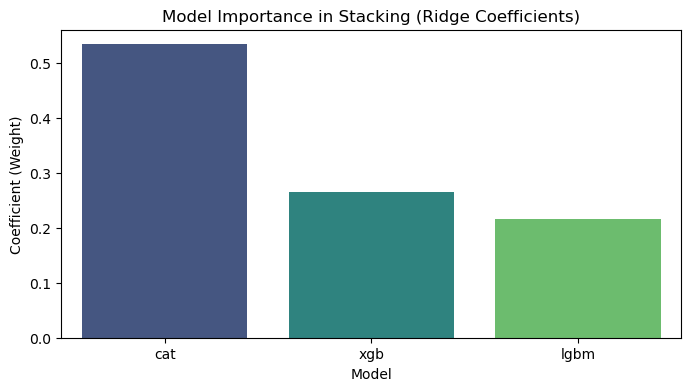


--- Top Features (from best base model: XGB) ---
RATIO_AveOccup_div_MedInc      0.356427
RATIO_MedInc_div_AveOccup      0.151836
MULT_Dist_SF_x_Dist_LA         0.094952
RATIO_Dist_LA_div_Dist_SF      0.055343
RATIO_Dist_SF_div_MedInc       0.030430
MULT_MedInc_x_AveBedrms        0.024512
SQUARE_MedInc                  0.016156
Longitude                      0.016110
RATIO_AveBedrms_div_Dist_SF    0.015478
RATIO_AveRooms_div_Dist_SF     0.014379
dtype: float32


Exception ignored in: <function ResourceTracker.__del__ at 0x102d3d800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [4]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# --- Run Feature Generation ---
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_manual_combinations(X, cols_for_math)

# Post-generation cleanup
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)
print(f"   -> Total features created: {X_full.shape[1]}")

# ---------------------------------------------------------
# 3. FEATURE SELECTION (LASSO)
# ---------------------------------------------------------
print("3. Intelligent Feature Selection (Lasso)...")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_full)

# LassoCV automatically selects the best alpha
lasso_selector = SelectFromModel(
    LassoCV(cv=3, random_state=42, n_jobs=-1, max_iter=2000)
)
lasso_selector.fit(X_scaled, y)

X_selected = X_full.loc[:, lasso_selector.get_support()]
print(f"   -> Features retained: {X_selected.shape[1]} (out of {X_full.shape[1]})")

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 4. ROBUST OPTUNA TUNING (3 MODELS)
# ---------------------------------------------------------
print("\n4. Robust Hyperparameter Tuning (internal 5-Fold CV)...")
kf = KFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS = 20  # Increase to 50+ for production

# --- A. XGBoost ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.6),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'alpha': trial.suggest_float('alpha', 1e-9, 15.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-9, 15.0, log=True),
        'n_jobs': -1,
        'random_state': 42
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()

print(" -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. LightGBM ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 120),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'n_jobs': -1,
        'verbose': -1,
        'random_state': 42
    }
    model = LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()

print(" -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# --- C. CatBoost ---
# Note: CatBoost is slower in pure CV. We reduce trials.
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 700, 1300),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.8),
        'depth': trial.suggest_int('depth', 1, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0,
        'allow_writing_files': False,
        'random_state': 42
    }
    model = CatBoostRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=1  # avoids conflicts
    )
    return -scores.mean()

print(" -> Optimizing CatBoost (may take time)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=10)

print(f"\nBEST CV RMSE -> XGB: {study_xgb.best_value:.4f} | "
      f"LGBM: {study_lgbm.best_value:.4f} | "
      f"CAT: {study_cat.best_value:.4f}")

# ---------------------------------------------------------
# 5. FINAL STACKING
# ---------------------------------------------------------
print("\n5. Final Stacking Ensemble...")

best_xgb = study_xgb.best_params
best_xgb.update({'n_jobs': -1, 'random_state': 42})

best_lgbm = study_lgbm.best_params
best_lgbm.update({'n_jobs': -1, 'verbose': -1, 'random_state': 42})

best_cat = study_cat.best_params
best_cat.update({'verbose': 0, 'allow_writing_files': False, 'random_state': 42})

estimators = [
    ('xgb', XGBRegressor(**best_xgb)),
    ('lgbm', LGBMRegressor(**best_lgbm)),
    ('cat', CatBoostRegressor(**best_cat))
]

# Meta learner combines predictions from base models
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),  # robust to collinearity
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)

# ---------------------------------------------------------
# 6. EVALUATION
# ---------------------------------------------------------
y_pred = stacking.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"\n==========================================")
print(f" FINAL TEST SET RESULTS (STACKING)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")

# --- 6.1 Meta-learner weights ---
print("\n--- Meta-Learner Weights Analysis (RidgeCV) ---")
meta_model = stacking.final_estimator_
model_names = [name for name, _ in stacking.estimators]
coefficients = meta_model.coef_

weights_df = pd.DataFrame({
    'Model': model_names,
    'Weight': coefficients
}).sort_values(by='Weight', ascending=False)

print(weights_df)
print(f"\nIntercept (Bias): {meta_model.intercept_:.4f}")

# Bar plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='Weight', data=weights_df, palette='viridis')
plt.title('Model Importance in Stacking (Ridge Coefficients)')
plt.ylabel('Coefficient (Weight)')
plt.show()

# --- 6.2 Top Features ---
print("\n--- Top Features (from best base model: XGB) ---")
xgb_fitted = stacking.estimators_[0]
importances = pd.Series(
    xgb_fitted.feature_importances_,
    index=X_train.columns
)
print(importances.sort_values(ascending=False).head(10))

**RESULT**


========================================== <br>
 FINAL TEST SET RESULTS (STACKING)
========================================== <br>
 RMSE: 0.38020
 R^2 : 0.83560
========================================== <br>

--- Meta-Learner Weight Analysis (RidgeCV) ---
  Model    Weight
2   cat  0.660385
0   xgb  0.193688
1  lgbm  0.155136

kf = KFold(n_splits=3, shuffle=True, random_state=42)
N_TRIALS = 20 # Increase to 50+ for production

# --- A. XGBoost ---
def objective_xgb(trial):
    params = {
        ‘n_estimators’: trial.suggest_int(‘n_estimators’, 600, 1200),
        ‘learning_rate’: trial.suggest_float(‘learning_rate’, 0.01, 0.1),
        'max_depth': trial.suggest_int(‘max_depth’, 3, 9),
        ‘subsample’: trial.suggest_float(‘subsample’, 0.6, 0.95),
        ‘colsample_bytree’: trial.suggest_float(‘colsample_bytree’, 0.6, 0.95),
        ‘reg_alpha’: trial.suggest_float(‘reg_alpha’, 0.1, 5),
        ‘reg_lambda’: trial.suggest_float(‘reg_lambda’, 0.1, 5),
        ‘n_jobs’: -1, ‘random_state’: 42
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring=‘neg_root_mean_squared_error’, n_jobs=-1)
    return -scores.mean()

print(“ -> Optimizing XGBoost...”)
study_xgb = optuna.create_study(direction=‘minimize’)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. LightGBM ---
def objective_lgbm(trial):
    params = {
        ‘n_estimators’: trial.suggest_int(‘n_estimators’, 600, 1200),
        ‘learning_rate’: trial.suggest_float(‘learning_rate’, 0.01, 0.1),
        'num_leaves': trial.suggest_int(‘num_leaves’, 20, 100),
        ‘feature_fraction’: trial.suggest_float(‘feature_fraction’, 0.6, 0.95),
        'bagging_fraction': trial.suggest_float(‘bagging_fraction’, 0.6, 0.95),
        ‘bagging_freq’: trial.suggest_int(‘bagging_freq’, 1, 7),
        ‘reg_alpha’: trial.suggest_float(‘reg_alpha’, 0.1, 5),
        'reg_lambda': trial.suggest_float(‘reg_lambda’, 0.1, 5),
        ‘n_jobs’: -1, ‘verbose’: -1, ‘random_state’: 42
    }
    model = LGBMRegressor(**params)

  scores = cross_val_score(model, X_train, y_train, cv=kf, scoring=‘neg_root_mean_squared_error’, n_jobs=-1)
    return -scores.mean()

print(“ -> Optimizing LightGBM...”)
study_lgbm = optuna.create_study(direction=‘minimize’)
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

# --- C. CatBoost ---
# Note: CatBoost in pure CV is slow. Let’s slightly reduce the space or the number of trials.
def objective_cat(trial):
    params = {
        ‘iterations’: trial.suggest_int(‘iterations’, 600, 1200),
        ‘learning_rate’: trial.suggest_float(‘learning_rate’, 0.01, 0.1),
        'depth': trial.suggest_int(‘depth’, 4, 10),
        ‘l2_leaf_reg’: trial.suggest_float(‘l2_leaf_reg’, 1, 10),
        'subsample': trial.suggest_float(‘subsample’, 0.6, 0.95),
        ‘verbose’: 0, ‘allow_writing_files’: False, ‘random_state’: 42
    }
    model = CatBoostRegressor(**params)
    # CatBoost handles multiprocessing differently; setting n_jobs=-1 in cross_val_score sometimes causes conflicts
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring=‘neg_root_mean_squared_error’, n_jobs=1)
    return scores.mean()

print(“ -> Optimizing CatBoost (may take some time)...”)
study_cat = optuna.create_study(direction=‘minimize’)
study_cat.optimize(objective_cat, n_trials=10) # Fewer trials for CatBoost, which is slow
